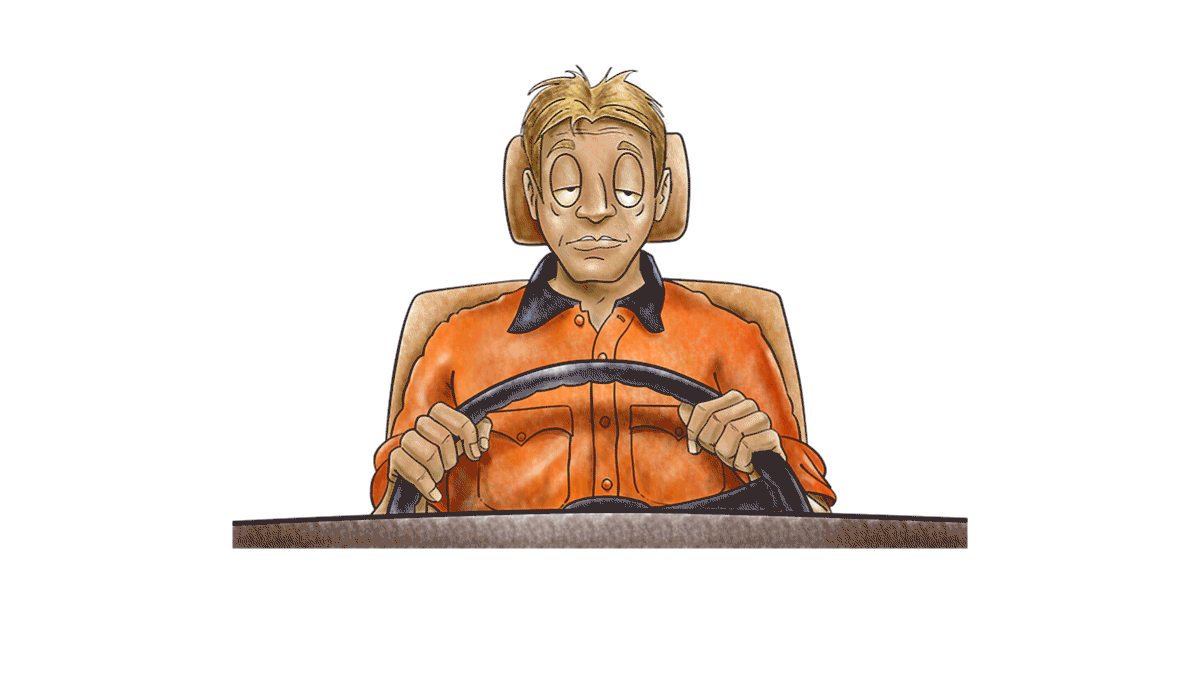

## Driver drowsiness detection is a car safety technology which helps prevent accidents caused by the driver getting drowsy. Various studies have suggested that around 20% of all road accidents are fatigue-related, up to 50% on certain roads.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2

# labels

In [2]:
labels = os.listdir("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train")

In [3]:
labels

['Open_Eyes', 'Closed_Eyes', 'Yawn', 'No_yawn']

# visualize random 1 image

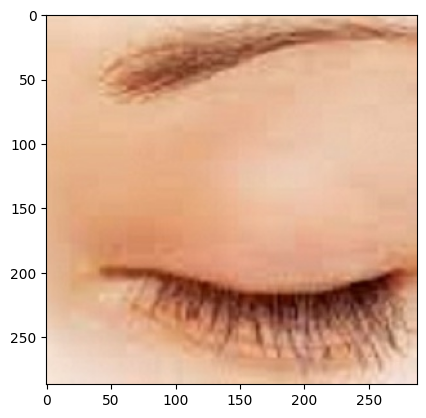

In [4]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Closed_Eyes/_100.jpg"))

# image array

In [5]:
a = plt.imread("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Yawn/100.jpg")

# image shape

In [6]:
a.shape

(77, 100, 3)

# visualize yawn image. 
# Here background is unnecessary. we need only face image array

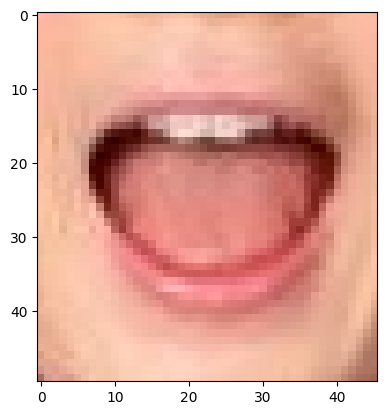

In [7]:
plt.imshow(plt.imread("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Yawn/1000.jpg"))

# for yawn and not_yawn. Take only face

In [8]:
def face_for_yawn(direc="/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train"):
    yaw_no = []
    IMG_SIZE = 145
    categories = ["Yawn", "No_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            try:
                image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
                if image_array is None:
                    continue
                resized_array = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE))
                if resized_array.shape != (IMG_SIZE, IMG_SIZE, 3):
                    continue
                yaw_no.append([resized_array, class_num1])
            except Exception as e:
                print(e)
    return yaw_no


yawn_no_yawn = face_for_yawn()

0
1


# for closed and open eye

In [9]:
def get_data(dir_path="/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train", face_cas="../input/prediction-images/haarcascade_frontalface_default.xml", eye_cas="../input/prediction-images/haarcascade.xml"):
    labels = ['Closed_Eyes', 'Open_Eyes']
    IMG_SIZE = 145
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                if resized_array.shape != (IMG_SIZE, IMG_SIZE, 3):
                    continue
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data

In [10]:
data_train = get_data()

2
3


In [11]:
# for head pose (front and down)
def get_head_pose_data(dir_path="/kaggle/input/datasets/antuchowdhury112/headpose/train"):
    categories = ["front", "down"]
    IMG_SIZE = 145
    head_data = []
    for category in categories:
        path = os.path.join(dir_path, category)
        class_num = categories.index(category) + 4
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                if resized_array.shape != (IMG_SIZE, IMG_SIZE, 3):
                    continue
                head_data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return head_data

# extend data and convert array

In [12]:
def append_data():
    yaw_no = face_for_yawn()
    data = get_data()
    head_data = get_head_pose_data()
    yaw_no.extend(data)
    yaw_no.extend(head_data)
    features = np.array([item[0] for item in yaw_no])
    labels = np.array([item[1] for item in yaw_no])
    return list(zip(features, labels))

# new variable to store

In [13]:
new_data = append_data()

0
1
2
3
4
5


# separate label and features

In [14]:
X = []
y = []
for feature, label in new_data:
    X.append(feature)
    y.append(label)

# reshape the array

In [15]:
X = np.array(X)
X = X.reshape(-1, 145, 145, 3)

# LabelBinarizer

In [16]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

# label array

In [17]:
y = np.array(y)

# train test split

In [18]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

# length of X_test

In [19]:
len(X_test)

3834

# Not necessary, only use to matching with my pc version

In [20]:
# !pip install tensorflow==2.3.1
# !pip install keras==2.4.3

# import some dependencies

In [21]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

2026-04-06 22:15:37.711239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775513737.730759    1465 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775513737.736800    1465 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775513737.751542    1465 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775513737.751557    1465 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775513737.751559    1465 computation_placer.cc:177] computation placer alr

# tensorflow version

In [22]:
tf.__version__

'2.19.0'

# keras version

In [23]:
import keras
keras.__version__

'3.10.0'

# Data Augmentation

In [24]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

# Model

In [25]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dense(6, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775513745.067218    1465 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775513745.072388    1465 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 143, 143, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 71, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,270 (1.89 MB)

 Trainable params: 495,270 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(train_generator, epochs=50, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775513748.024581    1529 service.cc:152] XLA service 0x7af734047a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775513748.024622    1529 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775513748.024626    1529 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775513748.382306    1529 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 22:15:52.748011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:15:52.987458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/280 ━━━━━━━━━━━━━━━━━━━━ 55:53 12s/step - accuracy: 0.1562 - loss: 1.8077

I0000 00:00:1775513758.132683    1529 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 61/280 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - accuracy: 0.2595 - loss: 1.6805

2026-04-06 22:16:08.676589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:16:08.910304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:16:10.055047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:16:10.283485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:16:10.765484: E external/local_xla/xla/stream_

280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5337 - loss: 1.1446

2026-04-06 22:16:56.629689: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:16:56.876683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


280/280 ━━━━━━━━━━━━━━━━━━━━ 72s 214ms/step - accuracy: 0.5344 - loss: 1.1432 - val_accuracy: 0.9098 - val_loss: 0.2768
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.8801 - loss: 0.3486 - val_accuracy: 0.9335 - val_loss: 0.2004
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.9027 - loss: 0.2775 - val_accuracy: 0.9476 - val_loss: 0.1587
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.9233 - loss: 0.2394 - val_accuracy: 0.9450 - val_loss: 0.1568
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.9299 - loss: 0.2105 - val_accuracy: 0.9564 - val_loss: 0.1337
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 165ms/step - accuracy: 0.9388 - loss: 0.1823 - val_accuracy: 0.9614 - val_loss: 0.1153
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 163ms/step - accuracy: 0.9480 - loss: 0.1602 - val_accuracy: 0.9567 - val_loss: 0.1197
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 47s 168ms/step - accuracy: 0.9445 - loss: 0.1706 - val

# history

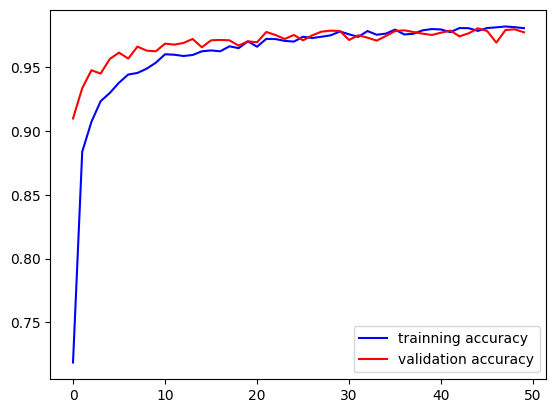

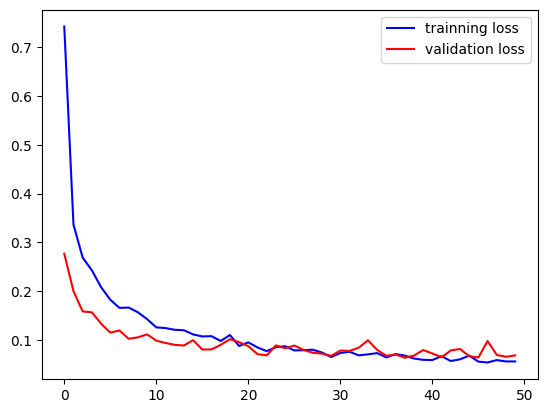

In [27]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()

# save model

In [28]:
model.save("drowiness_new6.h5")

In [30]:
model.save("/kaggle/working/drowsiness_v2.keras")

# Prediction

In [31]:
prediction = model.predict_classes(X_test)

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [32]:
prediction

NameError: name 'prediction' is not defined

# classification report

In [ ]:
labels_new = ["Yawn", "No_yawn", "Closed_Eyes", "Open_Eyes", "front", "down"]

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), prediction, target_names=labels_new))

# predicting function

In [ ]:
labels_new = ["Yawn", "No_yawn", "Closed_Eyes", "Open_Eyes", "front", "down"]
IMG_SIZE = 145
def prepare(filepath, face_cas="../input/prediction-images/haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model("./drowiness_new6.h5")

# Prediction 
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open

In [33]:
# prepare("../input/drowsiness-dataset/train/no_yawn/1068.jpg")
prediction = model.predict([prepare("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/No_yawn/1008.jpg")])
np.argmax(prediction)

NameError: name 'prepare' is not defined

In [ ]:
prediction = model.predict([prepare("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Closed_Eyes/_102.jpg")])
np.argmax(prediction)

In [ ]:
prediction = model.predict([prepare("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Open_Eyes/_104.jpg")])
np.argmax(prediction)

In [ ]:
prediction = model.predict([prepare("/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Train/Yawn/1007.jpg")])
np.argmax(prediction)

# If you like please upvote